In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import itertools
import pandas as pd

# Set a nice default style
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12

In [3]:
def generate_mixture_spectra(
    df,
    wavelength_col="Wavelength",
    combination_sizes=(2, 3),
    n_mixtures_per_combination=5,
    random_state=42
):
    """
    df: DataFrame with one wavelength column and one column per pure spectrum.
        Example columns: ['Wavelength', 'Diatom_Ptricornutum', ...]
    wavelength_col: name of the wavelength column.
    combination_sizes: tuple with sizes of combinations (e.g. (1, 2, 3, 4)).
        - 1 means single-species "mixtures" (i.e. just that pure spectrum again).
    n_mixtures_per_combination: number of random weightings per given combination.
    random_state: seed for reproducibility.

    Returns:
        mixtures_df: DataFrame with:
            - the wavelength column
            - one column per pure spectrum (copied from df)
            - additional columns for artificial mixtures
        weights_df: DataFrame that stores the weights used for each mixture column
            (so you know the exact composition).
    """
    rng = np.random.default_rng(random_state)

    # All species columns
    spectrum_cols = [c for c in df.columns if c != wavelength_col]

    # To store composition (weights) for each mixture column
    weights_records = []

    new_mixtures_dict = {}

    for k in combination_sizes:
        # All k-element combinations of the spectrum columns
        for comb in itertools.combinations(spectrum_cols, k):
            comb_name_base = "_".join(comb)

            for m in range(n_mixtures_per_combination):
                # Random non-negative weights that sum to 1
                weights = rng.dirichlet(np.ones(k))

                # Linear combination: mix = sum_i w_i * spectrum_i
                mix_spectrum = np.zeros(len(df))
                for col, w in zip(comb, weights):
                    mix_spectrum += w * df[col].values

                # Unique column name for this mixture
                mix_col_name = f"mix{k}_{comb_name_base}_{m}"

                new_mixtures_dict[mix_col_name] = mix_spectrum

                # Store the weights and which species were used
                record = {"mixture_name": mix_col_name}
                for col, w in zip(comb, weights):
                    record[col] = w
                weights_records.append(record)

    new_mixtures_df = pd.DataFrame(new_mixtures_dict)
    mixtures_df = pd.concat([df, new_mixtures_df], axis=1)

    weights_df = pd.DataFrame(weights_records).fillna(0.0)

    return mixtures_df, weights_df

In [4]:
df = pd.read_excel('Spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs

# if there is a NaN, interpolate data linearly

wavelength = df['Wavelength']
abs_spectra = df.iloc[:, 1:].to_numpy().T

# for spectrum in abs_spectra:
#     plt.plot(wavelength, spectrum)
# plt.show()

In [5]:
def data_creation(N_training_, N_validation_, noise_level_, abs_spectra_):
    # set seed for reproduction purposes
    N_species = len(abs_spectra_)
    N_wavelengths = len(wavelength)
    X = torch.zeros(N_species, (N_training_ + N_validation_), N_wavelengths)
    y = torch.zeros(N_species, (N_training_ + N_validation_), dtype=torch.long) # class needs integer 

    for specie_index, spectra in enumerate(abs_spectra_):
        data = torch.zeros(N_training_ + N_validation_, N_wavelengths)
        
        for i in range(N_training_ + N_validation_):
            data[i, :] = torch.tensor(spectra, dtype=torch.float32) + noise_level_ * torch.randn(N_wavelengths)

        X[specie_index] = data
        y[specie_index] = torch.zeros(N_training_ + N_validation_, dtype=torch.long) + int(specie_index)

    # shuffle first
    perm = torch.randperm(X.shape[1])
    X, y = X[:, perm, :], y[:, perm]
    
    # compute stats on training portion only
    mean = X[:, :N_training_, :].mean(dim=(1,2), keepdim=True)
    std  = X[:, :N_training_, :].std(dim=(1,2),  keepdim=True) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets into training and validation
    X_train_, y_train_ = X_norm[:, :N_training_, :], y[:, :N_training_]
    X_val_,   y_val_   = X_norm[:, N_training_:, :], y[:, N_training_:]
    return X_train_, y_train_, X_val_, y_val_

In [6]:
noise_level = .1
N_training = 4000
N_validation = int(N_training * .2)
X_train, y_train, X_val, y_val = data_creation(N_training, N_validation, noise_level, abs_spectra)

In [7]:
def training_loop(nr_epochs, epochs_no_improvement, X_train_, y_train_, X_val_, y_val_):
    N_species = len(y_val_)
    model_1 = nn.Sequential(
    nn.Linear(len(wavelength), 64),
    nn.ReLU(),
    nn.Linear(64, N_species)
    )
    model_2 = nn.Sequential(
    nn.Linear(len(wavelength), 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, N_species)
    )
    model_3 = nn.Sequential(
    nn.Linear(len(wavelength), 128),
    nn.ReLU(),
    nn.Linear(128, N_species)
    )

    model = model_3
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    # changes learning rate for better learning
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor = 0.5, min_lr = 1e-6)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs   = []
    epochs_list = []

    X_train_ = X_train_.reshape(-1, len(wavelength))        # (9*200, 451) = (1800, 451)
    X_val_ = X_val_.reshape(-1,len(wavelength))
    y_train_ = y_train_.reshape(-1)           # (1800,)
    y_val_ = y_val_.reshape(-1)

    best_val_loss = float('inf')

    for epoch in range(nr_epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train_).squeeze()
        
        # input should be (Ntraining * Nclasses, Nwavelength)
        loss = nn.CrossEntropyLoss()(pred[:, :], y_train_)
        loss.backward()
        optimizer.step()

        # find probability of logit (pred)
        prob = nn.Softmax(dim=1)(pred)
        class_choice = torch.argmax(prob, dim = 1)

        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_).squeeze() # same shape as y_val
            loss_val = nn.CrossEntropyLoss()(pred_val[:], y_val_)

            prob_val = nn.Softmax(dim=1)(pred_val)
            class_choice_val = torch.argmax(prob_val, dim = 1)
            
        # if true, we return a 1. Else 0.
        train_acc = (class_choice == y_train_).float().mean().item() * 100
        val_acc = (class_choice_val == y_val_).float().mean().item() * 100

        train_losses.append(loss.item())
        val_losses.append(loss_val.item()) 
        train_accs.append(train_acc)
        val_accs.append(val_acc) 
        epochs_list.append(epoch)

        # if validation loss grows, break loop
        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement > epochs_no_improvement:
            print(f"Early stopping at epoch {epoch}")
            break
        scheduler.step(loss_val.item())
    return train_losses, val_losses, train_accs, val_accs, epochs_list, model


In [8]:
train_losses, val_losses, train_accs, val_accs, epochs_list, trained_model = training_loop(1000, 0, X_train, y_train, X_val, y_val)

Early stopping at epoch 293


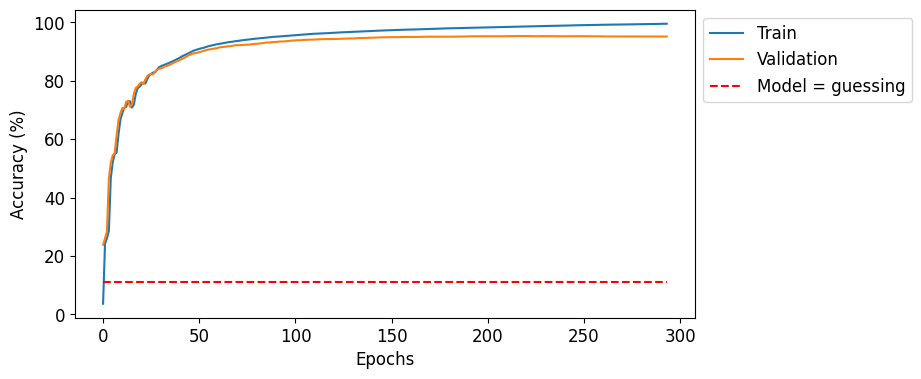

In [9]:
plt.plot(epochs_list, train_accs, label = 'Train')
plt.plot(epochs_list, val_accs, label = 'Validation')
plt.hlines(100/9, 0, epochs_list[-1], linestyles='--', color ='red', label = 'Model = guessing')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

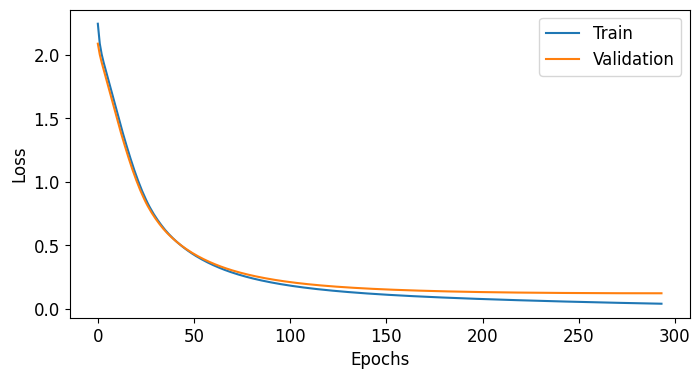

In [10]:
plt.plot(epochs_list, train_losses, label = 'Train')
plt.plot(epochs_list, val_losses, label = 'Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

 Linear combination -- check if model works

In [11]:
def data_creation_mixed_spectra(noise_level_):
    '''This function outputs a noisy absorption spectrum, normalized with mean and standard deviation.'''
    mixture_spectra_full, weights_spectra = generate_mixture_spectra(df, combination_sizes = (8,9))
    mixture_spectra_full = mixture_spectra_full.to_numpy()

    weight_values = weights_spectra.drop(columns="mixture_name").to_numpy(dtype=float) # shape (600,9) (samples, species)
    mixture_spectra = mixture_spectra_full[:,10:].astype(float).T # shape (600, 451)(samples, wavelengths)
    number_of_samples, _ = mixture_spectra.shape
    
    X = torch.tensor(mixture_spectra, dtype=torch.float32) + noise_level_ * torch.randn(mixture_spectra.shape)
    y = torch.tensor(weight_values, dtype = torch.float32)

    perm = torch.randperm(X.shape[0])

    X, y = X[perm], y[perm]

    # separate into training and validation data
    N_training = int(number_of_samples * .8)
    # N_validation = int(number_of_samples * .2)

    # compute stats on training portion only
    mean = X[:N_training].mean(dim=0)
    std  = X[:N_training].std(dim=0) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets
    X_train_, y_train_ = X_norm[:N_training],  y[:N_training]
    X_val_,   y_val_   = X_norm[N_training:],  y[N_training:]
    return X_train_, y_train_, X_val_, y_val_

In [14]:
accuracy_list = []
for _ in range(1000):
    X_comb_spectra, y_comb_spectra, _, _ = data_creation_mixed_spectra(noise_level)

    pred_comb = trained_model(X_comb_spectra).squeeze()
    prob_comb = nn.Softmax(dim=1)(pred_comb)
    nr_spectra, _ = X_comb_spectra.shape

    pred_top2 = torch.topk(prob_comb, k=2, dim=1)
    actual_top2 = torch.topk(y_comb_spectra, k = 2, dim = 1)

    pred_first_max = pred_top2.indices[:, 0]  # index of first highest
    actual_first_max = actual_top2.indices[:,0]

    accuracy_first = (pred_first_max == actual_first_max).float().mean().item() * 100
    accuracy_list.append(accuracy_first)
    
print(np.mean(accuracy_list), np.std(accuracy_list))

2.2700000341981648 1.160646390613163


In [15]:

pred_all = torch.topk(prob_comb, k = 9, dim = 1)
actual_all = torch.topk(y_comb_spectra, k = 9, dim = 1)
# checks if whole list is in correct order

accuracy = (pred_all.indices == actual_all.indices).float().mean().item() * 100
print(accuracy)
print(f'Random guess:{100/9}')

10.000000149011612
Random guess:11.11111111111111


['Diatom_Ptricornutum', 'Diatom_Csimplex', 'Chlamydomonas_Cpriscuii', 'Chlamydomonas_Creindhardtii', 'Dinoflagellate_Symbiodiniumsp', 'Dinoflagellate_Smicroadriaticum', 'Dinoflagellate_Dtrenchii', 'Dinoflagellate_Cgoreaui', 'Cyanobacteria_Synechosystis']


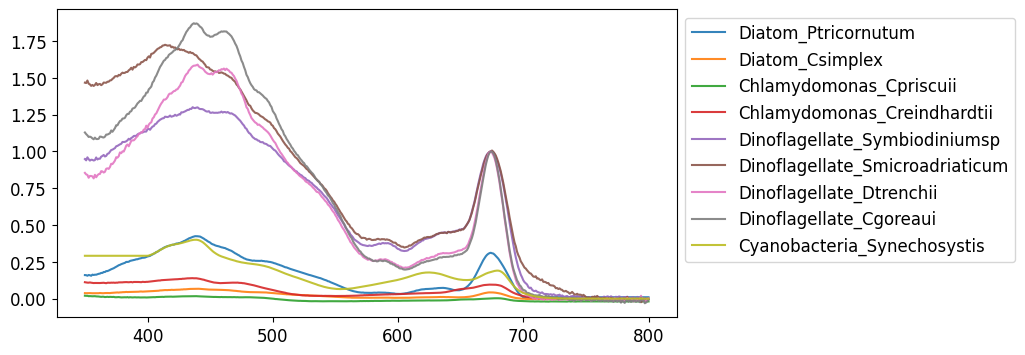

In [18]:
mixture_spectra_full, weights_spectra = generate_mixture_spectra(df)
mixture_spectra_full = mixture_spectra_full.to_numpy()
mixture_spectra = mixture_spectra_full.astype(float).T # shape (600, 451)(samples, wavelengths)
species_names = df.columns[1:].tolist()   # adjust if needed
print(species_names)
for i, pure in enumerate(mixture_spectra[1:10, :]):
    plt.plot(wavelength, pure, alpha = .9, label = species_names[i])
plt.legend(bbox_to_anchor = (1,1))

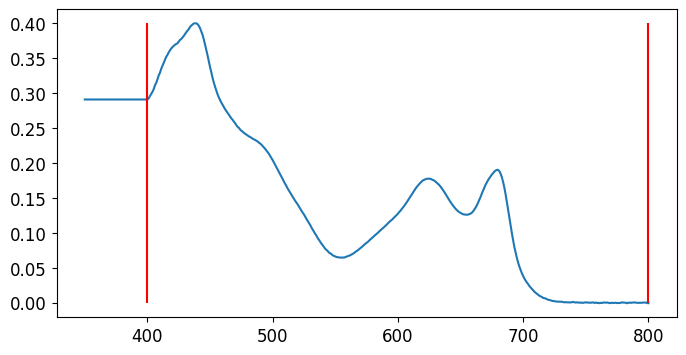

In [ ]:
plt.plot(wavelength, mixture_spectra[9, :])
plt.vlines(400, 0, 0.40, color = 'red')
plt.vlines(800, 0, 0.40, color = 'red')

plt.show()